# Part 3 Noise Label Identification 对脏crop数据的识别清洗

In [1]:
import httpx
#from bs4 import BeautifulSoup
import re
import json
import pandas as pd
import os
import random
import time
import openai
import requests
import torch
import sqlite3
from PIL import Image, ImageOps
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection,pipeline
from accelerate import Accelerator
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
load_dotenv(override=True)
from huggingface_hub import login
login(token=os.getenv("HUGGINGFACEHUB_API_TOKEN"))
current_dir = os.getcwd()
PROJECT_ROOT = os.path.dirname(os.path.dirname(current_dir))
db_path = os.path.join(PROJECT_ROOT, "data", "commons_image_manifest.sqlite")

def load_img_with_orientation(path):
    img = Image.open(path).convert("RGB")
    img = ImageOps.exif_transpose(img)  # 确保方向正确
    return img

OPENAI_MODEL_NAME = "gpt-5.4-mini"
LOCAL_VLM_NAME = "qwen/qwen3.6-27b"
LM_STUDIO_ENDPOINT = "http://127.0.0.1:1234"
PROJECT_ROOT


'c:\\Users\\fengy\\wakareeru'

In [2]:
with sqlite3.connect(db_path) as conn:
    count = pd.read_sql_query("""
SELECT series, COUNT(*) AS n
FROM crops
GROUP BY series
ORDER BY n DESC;
""",conn)
count

,series,n
0,キハ40系,828
1,E231系,286
2,C57形,274
3,E233系,242
4,E5系,179
5,E6系,134
6,DD51形,123
7,キハ100系,98
8,EF510形,45
9,キハ141系,33


## Loss Trick的噪声检测

直觉：小的模型（例如一个线性分类头）的记忆能力较差，在刚开始Underfit时对噪声样本的拟合较差，易给出高loss，而在之后被记住之后loss会降低，形成大方差。与此同时加上循环learning rate,即lr下降到最低时使其跳变到最高范围，将模型打出overfit区间，此时又可以观察到噪声的loss。记录下来之后给出均值方差，应该可以看出噪声。

### 1.0 Crop加载配置和manifest


In [3]:
from pathlib import Path
from typing import Callable

import numpy as np

# Demo阶段的决策：
# - 先在线裁剪：bbox、padding、resize策略还在试，迭代最快，也不重复占磁盘。
# - 策略稳定后再离线缓存：多epoch反复训练同一批crop时再用materialize_crops。
# - batch里按原图路径复用已打开图片，避免同一原图的多个crop重复IO。
DATA_ROOT = Path(PROJECT_ROOT) / "data"
IMG_ROOT = DATA_ROOT
CROP_CACHE_ROOT = DATA_ROOT / "crops_demo"


def load_crop_manifest(
    db_path=db_path,
    series: list[str] | None = None,
    power_type: str | None = None,
    crop_status: str | None = None,
    min_score: float | None = None,
    limit: int | None = None,
    shuffle: bool = False,
    seed: int = 42,
) -> pd.DataFrame:
    """从SQLite读取crop元数据，并拼上本地原图路径。"""
    where = ["i.downloaded_path IS NOT NULL", "i.downloaded_path != ''"]
    params: list[object] = []

    if series:
        where.append("c.series IN (" + ",".join(["?"] * len(series)) + ")")
        params.extend(series)
    if power_type is not None:
        where.append("c.power_type = ?")
        params.append(power_type)
    if crop_status is not None:
        where.append("c.crop_status = ?")
        params.append(crop_status)
    if min_score is not None:
        where.append("COALESCE(c.detector_score, 0) >= ?")
        params.append(min_score)

    # 在pandas里抽样，保证demo可以用seed复现。
    sql_limit = None if shuffle else limit
    limit_sql = "LIMIT ?" if sql_limit is not None else ""
    if sql_limit is not None:
        params.append(limit)

    sql = f"""
    SELECT
        c.id AS crop_id,
        c.image_id,
        c.crop_index,
        c.series,
        c.power_type,
        c.detector_label,
        c.detector_score,
        c.box_x1, c.box_y1, c.box_x2, c.box_y2,
        i.downloaded_path,
        i.file_title,
        i.width AS image_width,
        i.height AS image_height
    FROM crops c
    JOIN images i ON i.id = c.image_id
    WHERE {' AND '.join(where)}
    ORDER BY c.id
    {limit_sql}
    """
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(sql, conn, params=params)

    if shuffle and len(df):
        n = min(limit or len(df), len(df))
        df = df.sample(n=n, random_state=seed).reset_index(drop=True)
    return df


### 1.0.1 在线裁剪和tensor转换


In [4]:
def _source_image_path(row: pd.Series | dict, img_root: Path = IMG_ROOT) -> Path:
    path = Path(row["downloaded_path"])
    return path if path.is_absolute() else img_root / path


def _expanded_box(row: pd.Series | dict, image_size: tuple[int, int], pad_frac: float = 0.04):
    width, height = image_size
    x1, y1, x2, y2 = (float(row[k]) for k in ["box_x1", "box_y1", "box_x2", "box_y2"])
    pad = max(x2 - x1, y2 - y1) * pad_frac
    left = max(0, int(np.floor(x1 - pad)))
    top = max(0, int(np.floor(y1 - pad)))
    right = min(width, int(np.ceil(x2 + pad)))
    bottom = min(height, int(np.ceil(y2 + pad)))
    if right <= left or bottom <= top:
        raise ValueError(f"bad crop box for crop_id={row.get('crop_id', row.get('id'))}: {(left, top, right, bottom)}")
    return left, top, right, bottom


def crop_from_image(
    img: Image.Image,
    row: pd.Series | dict,
    pad_frac: float = 0.04,
    resize: int | tuple[int, int] | None = 224,
) -> Image.Image:
    crop = img.crop(_expanded_box(row, img.size, pad_frac=pad_frac))
    if resize is not None:
        size = (resize, resize) if isinstance(resize, int) else resize
        crop = crop.resize(size, Image.Resampling.BICUBIC)
    return crop


def load_crop(
    row: pd.Series | dict,
    img_root: Path = IMG_ROOT,
    pad_frac: float = 0.04,
    resize: int | tuple[int, int] | None = 224,
) -> Image.Image:
    img = load_img_with_orientation(_source_image_path(row, img_root=img_root))
    return crop_from_image(img, row, pad_frac=pad_frac, resize=resize)


def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1).contiguous()


### 1.0.2 Batch迭代器


In [5]:
def encode_labels(rows: pd.DataFrame, label_col: str = "series", label_to_id: dict[str, int] | None = None):
    if label_to_id is None:
        labels = sorted(rows[label_col].dropna().astype(str).unique())
        label_to_id = {label: idx for idx, label in enumerate(labels)}
    y = torch.tensor([label_to_id[str(x)] for x in rows[label_col]], dtype=torch.long)
    return y, label_to_id


def load_crop_batch(
    rows: pd.DataFrame,
    img_root: Path = IMG_ROOT,
    pad_frac: float = 0.04,
    resize: int | tuple[int, int] | None = 224,
    transform: Callable[[Image.Image], object] | None = None,
    as_tensor: bool = True,
):
    """返回(batch, meta)。batch内会复用同一原图的已打开图片。"""
    image_cache: dict[Path, Image.Image] = {}
    items = []

    for _, row in rows.iterrows():
        src_path = _source_image_path(row, img_root=img_root)
        if src_path not in image_cache:
            image_cache[src_path] = load_img_with_orientation(src_path)
        item = crop_from_image(image_cache[src_path], row, pad_frac=pad_frac, resize=resize)
        item = transform(item) if transform is not None else (pil_to_tensor(item) if as_tensor else item)
        items.append(item)

    if as_tensor and items and all(isinstance(x, torch.Tensor) for x in items):
        items = torch.stack(items)
    return items, rows.reset_index(drop=True)


def iter_crop_batches(
    rows: pd.DataFrame,
    batch_size: int = 32,
    label_col: str = "series",
    label_to_id: dict[str, int] | None = None,
    shuffle: bool = True,
    seed: int = 42,
    **crop_kwargs,
):
    """Notebook里直接训练轻量分类头用的简单batch迭代器。"""
    work = rows.sample(frac=1, random_state=seed).reset_index(drop=True) if shuffle else rows.reset_index(drop=True)
    if label_to_id is None:
        _, label_to_id = encode_labels(work, label_col=label_col)
    for start in range(0, len(work), batch_size):
        meta = work.iloc[start:start + batch_size].reset_index(drop=True)
        x, meta = load_crop_batch(meta, **crop_kwargs)
        y, _ = encode_labels(meta, label_col=label_col, label_to_id=label_to_id)
        yield x, y, meta


### 1.0.3 可选离线缓存


In [6]:
def materialize_crops(
    rows: pd.DataFrame,
    out_root: Path = CROP_CACHE_ROOT,
    pad_frac: float = 0.04,
    resize: int | tuple[int, int] | None = 224,
    overwrite: bool = False,
) -> pd.DataFrame:
    """可选离线缓存。等crop策略稳定后再用。"""
    out_root.mkdir(parents=True, exist_ok=True)
    records = []
    for _, row in tqdm(rows.iterrows(), total=len(rows)):
        label_dir = out_root / str(row["series"])
        label_dir.mkdir(parents=True, exist_ok=True)
        out_path = label_dir / f"crop_{int(row['crop_id']):07d}.jpg"
        if overwrite or not out_path.exists():
            load_crop(row, pad_frac=pad_frac, resize=resize).save(out_path, quality=92)
        rec = row.to_dict()
        rec["crop_path"] = str(out_path.relative_to(DATA_ROOT))
        records.append(rec)
    return pd.DataFrame(records)


### 1.0.4 快速smoke test


In [7]:
# 快速检查notebook demo路径。
demo_rows = load_crop_manifest(series=['E5系','E6系','E231系','E233系','キハ40系', 'キハ100系'], limit=16, shuffle=True) #测试只取样本多的几个系列
demo_batch, demo_y, demo_meta = next(iter_crop_batches(demo_rows, batch_size=8, resize=224))
_, demo_label_to_id = encode_labels(demo_rows)
demo_batch.shape, demo_y.shape, demo_label_to_id, demo_meta[["crop_id", "series", "power_type", "detector_score"]].head()


(torch.Size([8, 3, 224, 224]),
 torch.Size([8]),
 {'E231系': 0, 'E233系': 1, 'E5系': 2, 'E6系': 3, 'キハ100系': 4, 'キハ40系': 5},
    crop_id series power_type  detector_score
 0     2456  キハ40系        DMU        0.751448
 1      253  キハ40系        DMU        0.630124
 2     2604  キハ40系        DMU        0.748373
 3     2083  E233系        EMU        0.301406
 4     1900  E231系        EMU        0.314340)

### 1.1模型和其他训练工具定义

In [8]:
import torch
import torch.nn as nn

class DINOHeadClassifier(nn.Module):
    def __init__(self, model_name: str, num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        
        self.model_name = model_name
        self.backbone = torch.hub.load('facebookresearch/dinov2', model_name)
        
        if freeze_backbone:
            for param in self.backbone.parameters(): # type:ignore
                param.requires_grad = False
        
        self.head = nn.Linear(self.backbone.embed_dim, num_classes) # type:ignore
    
    
    def forward(self, x):
        cls = self.backbone(x) # type:ignore 取聚合特征的cls token
        logits = self.head(cls)
        return logits

    def forward_with_features(self, x):
        cls = self.backbone(x) # type:ignore
        logits = self.head(cls)
        return cls, logits

    def foward_with_features(self, x):
        return self.forward_with_features(x)


### 1.2 Loss tracking训练和噪声样本分析


### 1.2.1 DINO输入变换和循环LR


In [9]:
import math

DINO_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
DINO_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def dino_transform(img: Image.Image) -> torch.Tensor:
    x = pil_to_tensor(img)
    return (x - DINO_MEAN) / DINO_STD


def linear_cycle_lr(step: int, max_lr: float, min_lr: float, c: int) -> float:
    """每个周期内从max_lr线性降到min_lr，周期结束后跳回max_lr。"""
    c = max(1, int(c))
    if c == 1:
        return max_lr
    phase = step % c
    return max_lr + (min_lr - max_lr) * (phase / (c - 1))


def _set_optimizer_lr(optimizer: torch.optim.Optimizer, lr: float) -> None:
    for group in optimizer.param_groups:
        group["lr"] = lr


def _forward_logits(model: nn.Module, x: torch.Tensor, train_backbone: bool = False) -> torch.Tensor:
    if train_backbone or not hasattr(model, "backbone") or not hasattr(model, "head"):
        return model(x)
    model.backbone.eval()  # type:ignore[attr-defined]
    with torch.no_grad():
        cls = model.backbone(x)  # type:ignore[attr-defined]
    return model.head(cls)  # type:ignore[attr-defined]


### 1.2.2 AdamW训练和per-sample loss tracking


In [10]:
def train_head_with_loss_tracking(
    model: nn.Module,
    rows: pd.DataFrame,
    label_col: str = "series",
    label_to_id: dict[str, int] | None = None,
    epochs: int = 6,
    batch_size: int = 32,
    max_lr: float = 3e-3,
    min_lr: float = 3e-5,
    c: int = 50,
    weight_decay: float = 1e-2,
    resize: int = 224,
    pad_frac: float = 0.04,
    device: str | torch.device | None = None,
    train_backbone: bool = False,
    seed: int = 42,
):
    """使用AdamW训练，并为每次看到的crop样本记录一条loss。"""
    if label_to_id is None:
        _, label_to_id = encode_labels(rows, label_col=label_col)
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    model = model.to(device)

    if train_backbone:
        params = [p for p in model.parameters() if p.requires_grad]
    else:
        for name, p in model.named_parameters():
            p.requires_grad = name.startswith("head.")
        params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=max_lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(reduction="none")

    loss_records = []
    epoch_records = []
    global_step = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_n = 0

        iterator = iter_crop_batches(
            rows,
            batch_size=batch_size,
            label_col=label_col,
            label_to_id=label_to_id,
            shuffle=True,
            seed=seed + epoch,
            resize=resize,
            pad_frac=pad_frac,
            transform=dino_transform,
            as_tensor=True,
        )

        for batch_idx, (x, y, meta) in enumerate(tqdm(iterator, total=math.ceil(len(rows) / batch_size), desc=f"epoch {epoch + 1}/{epochs}")):
            lr = linear_cycle_lr(global_step, max_lr=max_lr, min_lr=min_lr, c=c)
            _set_optimizer_lr(optimizer, lr)
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = _forward_logits(model, x, train_backbone=train_backbone)
            per_sample_loss = criterion(logits, y)
            loss = per_sample_loss.mean()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                pred = logits.argmax(dim=1)
                correct = pred.eq(y)

            losses_cpu = per_sample_loss.detach().cpu().tolist()
            pred_cpu = pred.detach().cpu().tolist()
            y_cpu = y.detach().cpu().tolist()
            correct_cpu = correct.detach().cpu().tolist()

            for i, row in meta.reset_index(drop=True).iterrows():
                loss_records.append({
                    "epoch": epoch,
                    "batch_idx": batch_idx,
                    "global_step": global_step,
                    "lr": lr,
                    "crop_id": int(row["crop_id"]),
                    "image_id": int(row["image_id"]),
                    "series": row[label_col],
                    "target": int(y_cpu[i]),
                    "pred": int(pred_cpu[i]),
                    "correct": bool(correct_cpu[i]),
                    "loss": float(losses_cpu[i]),
                    "detector_score": row.get("detector_score"),
                    "downloaded_path": row.get("downloaded_path"),
                    "file_title": row.get("file_title"),
                })

            running_loss += float(per_sample_loss.sum().detach().cpu())
            running_correct += int(correct.sum().detach().cpu())
            running_n += int(y.numel())
            global_step += 1

        epoch_records.append({
            "epoch": epoch,
            "loss": running_loss / max(1, running_n),
            "accuracy": running_correct / max(1, running_n),
            "n": running_n,
        })

    history = pd.DataFrame(loss_records)
    epoch_history = pd.DataFrame(epoch_records)
    return model, history, epoch_history, label_to_id


### 1.2.3 Loss和学习率绘图


In [11]:
def plot_loss_tracking(history: pd.DataFrame, epoch_history: pd.DataFrame | None = None, rolling: int = 64):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    step_loss = history.groupby("global_step", as_index=False).agg(loss=("loss", "mean"), lr=("lr", "first"))
    step_loss["loss_smooth"] = step_loss["loss"].rolling(rolling, min_periods=1).mean()

    axes[0].plot(step_loss["global_step"], step_loss["loss"], alpha=0.25, label="batch loss")
    axes[0].plot(step_loss["global_step"], step_loss["loss_smooth"], label=f"rolling {rolling}")
    axes[0].set_title("Training loss")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("cross entropy")
    axes[0].legend()

    axes[1].plot(step_loss["global_step"], step_loss["lr"], color="tab:orange")
    axes[1].set_title("Linear cyclic lr")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("lr")

    if epoch_history is not None and len(epoch_history):
        for _, row in epoch_history.iterrows():
            fig.text(0.01, 0.01 + 0.035 * int(row["epoch"]), f"epoch {int(row['epoch']) + 1}: loss={row['loss']:.3f}, acc={row['accuracy']:.3f}")
    plt.tight_layout()
    return fig


### 1.2.4 per-sample loss聚合和噪声候选展示


In [12]:
def summarize_sample_losses(history: pd.DataFrame, rows: pd.DataFrame | None = None) -> pd.DataFrame:
    stats = history.groupby("crop_id", as_index=False).agg(
        loss_mean=("loss", "mean"),
        loss_std=("loss", "std"),
        loss_max=("loss", "max"),
        loss_last=("loss", "last"),
        seen=("loss", "size"),
        error_rate=("correct", lambda x: 1.0 - float(np.mean(x))),
        series=("series", "first"),
        file_title=("file_title", "first"),
        downloaded_path=("downloaded_path", "first"),
        detector_score=("detector_score", "first"),
    )
    stats["loss_std"] = stats["loss_std"].fillna(0.0)
    for col in ["loss_mean", "loss_std", "loss_max", "loss_last", "error_rate"]:
        sigma = stats[col].std(ddof=0)
        stats[f"z_{col}"] = 0.0 if sigma == 0 else (stats[col] - stats[col].mean()) / sigma
    stats["noise_score"] = (
        stats["z_loss_mean"] +
        0.8 * stats["z_loss_std"] +
        0.8 * stats["z_loss_last"] +
        0.6 * stats["z_error_rate"]
    )

    if rows is not None:
        keep = [
            "crop_id", "image_id", "crop_index", "power_type", "detector_label",
            "box_x1", "box_y1", "box_x2", "box_y2",
        ]
        extra = rows[[c for c in keep if c in rows.columns]].drop_duplicates("crop_id")
        stats = stats.merge(extra, on="crop_id", how="left")
    return stats.sort_values("noise_score", ascending=False).reset_index(drop=True)


def show_noise_candidates(
    sample_stats: pd.DataFrame,
    top_k: int = 12,
    pad_frac: float = 0.04,
    resize: int = 224,
    cols: int = 4,
):
    top = sample_stats.head(top_k).reset_index(drop=True)
    rows_n = math.ceil(len(top) / cols)
    fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 3.4, rows_n * 3.9))
    axes = np.array(axes).reshape(-1)

    for ax in axes[len(top):]:
        ax.axis("off")

    for i, row in top.iterrows():
        crop = load_crop(row, pad_frac=pad_frac, resize=resize)
        ax = axes[i]
        ax.imshow(crop)
        ax.axis("off")
        ax.set_title(
            f"#{i + 1} crop {int(row['crop_id'])}\n"
            f"{row['series']} score={row['noise_score']:.2f}\n"
            f"mean={row['loss_mean']:.2f} std={row['loss_std']:.2f} err={row['error_rate']:.2f}",
            fontsize=9,
        )

    plt.tight_layout()
    display(top[["crop_id", "series", "noise_score", "loss_mean", "loss_std", "loss_last", "error_rate", "file_title"]])
    return fig, top


### 1.3 Feature cache：先缓存DINO特征


### 1.3.1 Feature cache配置


In [13]:
FEATURE_CACHE_ROOT = DATA_ROOT / "feature_cache"
FEATURE_CACHE_ROOT.mkdir(parents=True, exist_ok=True)


def _torch_load_cache(path: str | Path):
    path = Path(path)
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def _jsonable_record(row: pd.Series | dict) -> dict:
    record = {}
    data = row.to_dict() if hasattr(row, "to_dict") else dict(row)
    for key, value in data.items():
        if pd.isna(value):
            record[key] = None
        elif hasattr(value, "item"):
            record[key] = value.item()
        else:
            record[key] = value
    return record


def feature_cache_path(name: str, root: Path = FEATURE_CACHE_ROOT) -> Path:
    if not name.endswith(".pt"):
        name = f"{name}.pt"
    return root / name


### 1.3.2 抽取并保存DINO特征


In [14]:
def build_dino_feature_cache(
    model: DINOHeadClassifier,
    rows: pd.DataFrame,
    cache_path: str | Path,
    label_col: str = "series",
    label_to_id: dict[str, int] | None = None,
    batch_size: int = 64,
    resize: int = 224,
    pad_frac: float = 0.04,
    device: str | torch.device | None = None,
    dtype: torch.dtype = torch.float16,
    overwrite: bool = False,
):
    """把crop过一遍frozen DINO backbone，并把特征缓存到磁盘。"""
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if cache_path.exists() and not overwrite:
        return _torch_load_cache(cache_path)

    if label_to_id is None:
        _, label_to_id = encode_labels(rows, label_col=label_col)

    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    model = model.to(device)
    model.eval()
    model.backbone.eval()  # type:ignore[attr-defined]

    features = []
    labels = []
    meta_records = []

    iterator = iter_crop_batches(
        rows,
        batch_size=batch_size,
        label_col=label_col,
        label_to_id=label_to_id,
        shuffle=False,
        resize=resize,
        pad_frac=pad_frac,
        transform=dino_transform,
        as_tensor=True,
    )

    with torch.inference_mode():
        for x, y, meta in tqdm(iterator, total=math.ceil(len(rows) / batch_size), desc="extract DINO features"):
            x = x.to(device, non_blocking=True)
            cls = model.backbone(x)  # type:ignore[attr-defined]
            if isinstance(cls, (tuple, list)):
                cls = cls[0]
            if cls.ndim > 2:
                cls = cls[:, 0]
            features.append(cls.detach().to("cpu", dtype=dtype))
            labels.append(y.detach().cpu())
            meta_records.extend(_jsonable_record(row) for _, row in meta.iterrows())

    cache = {
        "features": torch.cat(features, dim=0),
        "labels": torch.cat(labels, dim=0).long(),
        "meta": meta_records,
        "label_to_id": label_to_id,
        "config": {
            "resize": resize,
            "pad_frac": pad_frac,
            "model_name": getattr(model, "model_name", None),
            "feature_dtype": str(dtype),
        },
    }
    cache["crop_ids"] = torch.tensor([int(r["crop_id"]) for r in meta_records], dtype=torch.long)
    torch.save(cache, cache_path)
    pd.DataFrame(meta_records).to_csv(cache_path.with_suffix(".csv"), index=False, encoding="utf-8-sig")
    return cache


def load_dino_feature_cache(cache_path: str | Path):
    return _torch_load_cache(cache_path)


def feature_cache_to_frame(cache: dict) -> pd.DataFrame:
    frame = pd.DataFrame(cache["meta"])
    frame["feature_index"] = range(len(frame))
    return frame


### 1.3.3 用缓存特征训练线性头


In [19]:
def iter_feature_batches(
    cache: dict,
    batch_size: int = 256,
    shuffle: bool = True,
    seed: int = 42,
):
    features = cache["features"]
    labels = cache["labels"]
    meta = cache["meta"]
    n = int(features.shape[0])
    if shuffle:
        generator = torch.Generator().manual_seed(seed)
        order = torch.randperm(n, generator=generator)
    else:
        order = torch.arange(n)

    for start in range(0, n, batch_size):
        idx = order[start:start + batch_size]
        batch_meta = [meta[int(i)] for i in idx]
        yield features[idx], labels[idx], pd.DataFrame(batch_meta)


def train_head_from_feature_cache(
    cache: dict,
    epochs: int = 30,
    batch_size: int = 256,
    max_lr: float = 3e-3,
    min_lr: float = 3e-5,
    c: int = 50,
    weight_decay: float = 1e-2,
    device: str | torch.device | None = None,
    seed: int = 42,
):
    """只用缓存特征训练线性头，保留和在线训练一致的per-sample loss history。"""
    features = cache["features"]
    label_to_id = cache["label_to_id"]
    num_features = int(features.shape[1])
    num_classes = len(label_to_id)
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))

    head = nn.Linear(num_features, num_classes).to(device)
    optimizer = torch.optim.AdamW(head.parameters(), lr=max_lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(reduction="none")

    loss_records = []
    epoch_records = []
    global_step = 0

    for epoch in range(epochs):
        head.train()
        running_loss = 0.0
        running_correct = 0
        running_n = 0

        iterator = iter_feature_batches(cache, batch_size=batch_size, shuffle=True, seed=seed + epoch)
        total = math.ceil(len(cache["labels"]) / batch_size)
        for batch_idx, (x, y, meta) in enumerate(tqdm(iterator, total=total, desc=f"cached epoch {epoch + 1}/{epochs}")):
            lr = linear_cycle_lr(global_step, max_lr=max_lr, min_lr=min_lr, c=c)
            _set_optimizer_lr(optimizer, lr)
            x = x.to(device, dtype=torch.float32, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = head(x)
            per_sample_loss = criterion(logits, y)
            loss = per_sample_loss.mean()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                pred = logits.argmax(dim=1)
                correct = pred.eq(y)

            losses_cpu = per_sample_loss.detach().cpu().tolist()
            pred_cpu = pred.detach().cpu().tolist()
            y_cpu = y.detach().cpu().tolist()
            correct_cpu = correct.detach().cpu().tolist()

            for i, row in meta.reset_index(drop=True).iterrows():
                loss_records.append({
                    "epoch": epoch,
                    "batch_idx": batch_idx,
                    "global_step": global_step,
                    "lr": lr,
                    "crop_id": int(row["crop_id"]),
                    "image_id": int(row["image_id"]),
                    "series": row["series"],
                    "target": int(y_cpu[i]),
                    "pred": int(pred_cpu[i]),
                    "correct": bool(correct_cpu[i]),
                    "loss": float(losses_cpu[i]),
                    "detector_score": row.get("detector_score"),
                    "downloaded_path": row.get("downloaded_path"),
                    "file_title": row.get("file_title"),
                })

            running_loss += float(per_sample_loss.sum().detach().cpu())
            running_correct += int(correct.sum().detach().cpu())
            running_n += int(y.numel())
            global_step += 1

        epoch_records.append({
            "epoch": epoch,
            "loss": running_loss / max(1, running_n),
            "accuracy": running_correct / max(1, running_n),
            "n": running_n,
        })

    return head, pd.DataFrame(loss_records), pd.DataFrame(epoch_records), label_to_id


### 1.3.4 Feature cache示例调用


Using cache found in C:\Users\fengy/.cache\torch\hub\facebookresearch_dinov2_main


cached epoch 1/50:   0%|          | 0/3 [00:00<?, ?it/s]

cached epoch 2/50:   0%|          | 0/3 [00:00<?, ?it/s]

cached epoch 3/50:   0%|          | 0/3 [00:00<?, ?it/s]

cached epoch 4/50:   0%|          | 0/3 [00:00<?, ?it/s]

...

cached epoch 50/50:   0%|          | 0/3 [00:00<?, ?it/s]

C:\Users\fengy\AppData\Local\Temp\ipykernel_22540\1645710423.py:62: UserWarning: Glyph 12461 (\N{KATAKANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengy\AppData\Local\Temp\ipykernel_22540\1645710423.py:62: UserWarning: Glyph 12495 (\N{KATAKANA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengy\AppData\Local\Temp\ipykernel_22540\1645710423.py:62: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


,crop_id,series,noise_score,loss_mean,loss_std,loss_last,error_rate,file_title
0,1193,キハ100系,26.377579,5.547235,2.475531,1.317677,1.00,File:EF81-140＋kiha110-222@Omiya.jpg
1,901,E233系,23.274656,4.201186,0.883627,2.727139,1.00,File:2018-05-06 Keikyu 1500 series.jpg
2,1221,キハ100系,17.396583,3.768646,1.317831,1.007346,1.00,File:JR East E233-0 set H49 & Kiha 110-200 set...
3,491,E231系,16.778576,3.053019,0.863147,1.678060,1.00,File:EF81 139＋E231 K5 at Miyahara Sta.jpg
4,1415,E6系,14.965313,2.963165,1.396871,0.777440,0.98,File:Shinkansen E6 and JR East 701 in Akita li...
5,514,E231系,12.517603,1.982910,0.578410,1.424217,1.00,File:Tobu Tojo Main Line Shinrinkoen Depot Ope...
6,2353,キハ40系,11.297372,2.137738,1.206413,0.721181,0.70,File:追分駅 - panoramio (2).jpg
7,2117,E233系,10.915374,1.863500,0.762143,0.896890,1.00,File:JRE E233-2000 at Nogizaka Station 2015-04...
8,2372,キハ40系,10.127402,1.708793,0.413441,1.112752,0.98,File:DMUs at Yonago Station.jpg
9,1056,キハ40系,9.949313,1.760764,0.693529,0.779429,0.98,File:Hakata station 2024 5.jpg


(<Figure size 1360x1170 with 12 Axes>,
     crop_id  loss_mean  loss_std  loss_max  loss_last  seen  error_rate  \
 0      1193   5.547235  2.475531  9.314022   1.317677    50        1.00   
 1       901   4.201186  0.883627  5.514324   2.727139    50        1.00   
 2      1221   3.768646  1.317831  5.494528   1.007346    50        1.00   
 3       491   3.053019  0.863147  5.005336   1.678060    50        1.00   
 4      1415   2.963165  1.396871  5.536466   0.777440    50        0.98   
 5       514   1.982910  0.578410  3.880733   1.424217    50        1.00   
 6      2353   2.137738  1.206413  4.554884   0.721181    50        0.70   
 7      2117   1.863500  0.762143  4.344252   0.896890    50        1.00   
 8      2372   1.708793  0.413441  2.796310   1.112752    50        0.98   
 9      1056   1.760764  0.693529  3.073848   0.779429    50        0.98   
 10       73   1.576154  0.417887  2.566873   1.084186    50        0.96   
 11     1466   1.530567  1.001814  4.861526   0.7

c:\Users\fengy\.conda\envs\py312uni\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 12461 (\N{KATAKANA LETTER KI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\fengy\.conda\envs\py312uni\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 12495 (\N{KATAKANA LETTER HA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\fengy\.conda\envs\py312uni\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


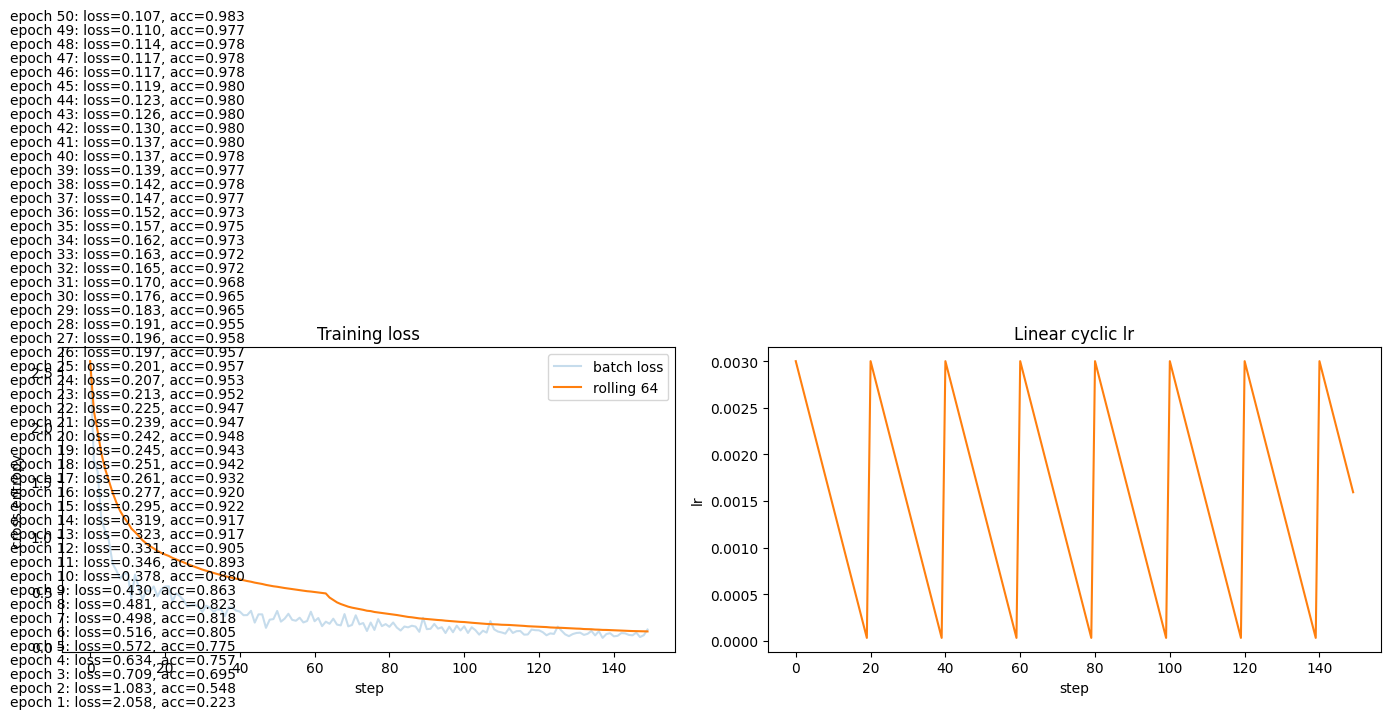

c:\Users\fengy\.conda\envs\py312uni\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12461 (\N{KATAKANA LETTER KI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\fengy\.conda\envs\py312uni\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12495 (\N{KATAKANA LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\fengy\.conda\envs\py312uni\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


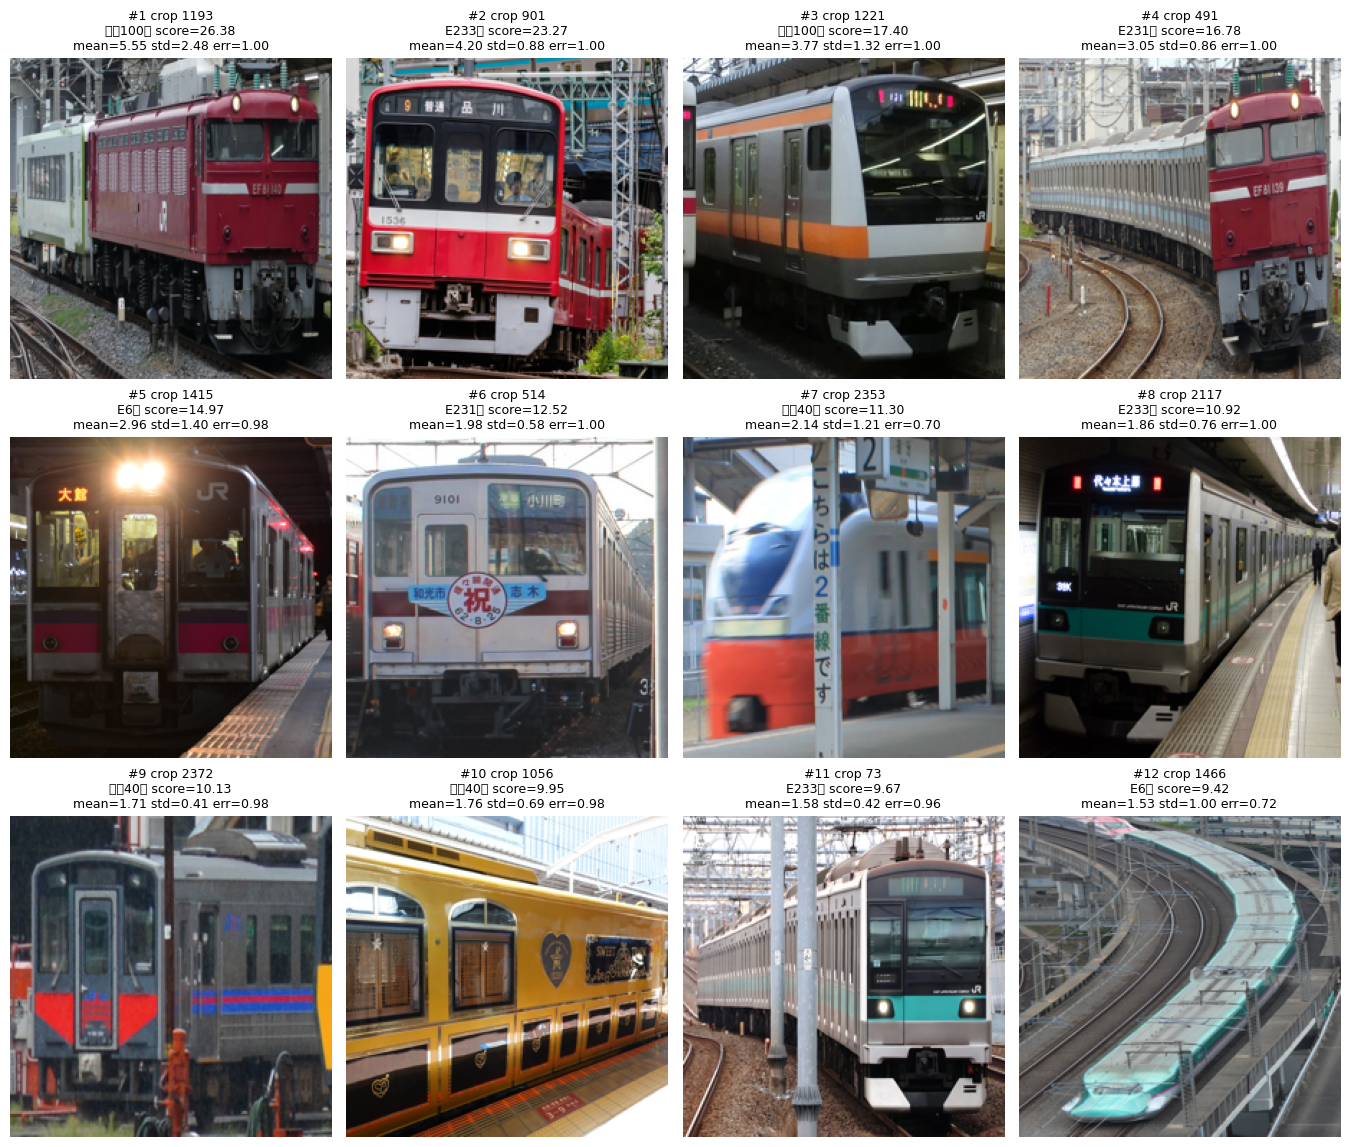

In [ ]:
# 示例：先抽一次DINO特征，再反复训练线性头做loss trick。
train_rows = load_crop_manifest(series=['E5系', 'E6系', 'E231系', 'E233系', 'キハ40系', 'キハ100系'], limit=600, shuffle=True)
_, label_to_id = encode_labels(train_rows)
backbone_model = DINOHeadClassifier('dinov2_vits14', num_classes=len(label_to_id), freeze_backbone=True)
cache = build_dino_feature_cache(
    backbone_model,
    train_rows,
    feature_cache_path('demo_dinov2_vits14_6series_600'),
    label_to_id=label_to_id,
    batch_size=64,
    overwrite=False,
)
head, loss_history, epoch_history, label_to_id = train_head_from_feature_cache(
    cache,
    epochs=50,
    batch_size=256,
    max_lr=3e-3,
    min_lr=3e-5,
    c=20,
)
plot_loss_tracking(loss_history, epoch_history)
sample_loss_stats = summarize_sample_losses(loss_history, train_rows)
show_noise_candidates(sample_loss_stats, top_k=50)


### 1.2.5 示例调用


In [17]:
# 示例调用：等上面的smoke test在notebook kernel里跑通后再取消注释。
# train_rows = load_crop_manifest(series=['E5系', 'E6系', 'E231系', 'E233系', 'キハ40系', 'キハ100系'], limit=600, shuffle=True)
# _, label_to_id = encode_labels(train_rows)
# model = DINOHeadClassifier('dinov2_vits14', num_classes=len(label_to_id), freeze_backbone=True)
# model, loss_history, epoch_history, label_to_id = train_head_with_loss_tracking(
#     model, train_rows, label_to_id=label_to_id, epochs=6, batch_size=32,
#     max_lr=3e-3, min_lr=3e-5, c=40, resize=224,
# )
# plot_loss_tracking(loss_history, epoch_history)
# sample_loss_stats = summarize_sample_losses(loss_history, train_rows)
# show_noise_candidates(sample_loss_stats, top_k=12)
